<a href="https://colab.research.google.com/github/sagarranaa/Banking_Support_Intent_Classifier/blob/main/banking_support_intent_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

sns.set_theme(style="whitegrid")

In [ ]:
#upload the traning csv
uploaded_train = files.upload()

if len(uploaded_train) != 1:
    raise ValueError("Upload exactly one training CSV.")

train_filename = next(iter(uploaded_train))

train_df = pd.read_csv(
    io.BytesIO(uploaded_train[train_filename])
)

print("Training file:", train_filename)
print("Training shape:", train_df.shape)

Saving train.csv to train (3).csv
Training file: train (3).csv
Training shape: (10003, 2)


In [ ]:
# upload the test csv
uploaded_test = files.upload()

if len(uploaded_test) != 1:
    raise ValueError("Upload exactly one test CSV.")

test_filename = next(iter(uploaded_test))

test_df = pd.read_csv(
    io.BytesIO(uploaded_test[test_filename])
)

print("Test file:", test_filename)
print("Test shape:", test_df.shape)

Saving test.csv to test (3).csv
Test file: test (3).csv
Test shape: (3080, 2)


In [ ]:
# check the columns
for name, frame in [
    ("Training", train_df),
    ("Test", test_df),
]:
    print(f"{name} columns:", frame.columns.tolist())

    required_columns = {"text", "category"}

    if not required_columns.issubset(frame.columns):
        raise ValueError(
            f"{name} CSV must contain text and category columns."
        )

train_df = train_df.rename(columns={"category": "label"})
test_df = test_df.rename(columns={"category": "label"})

display(train_df.sample(5, random_state=42))

Training columns: ['text', 'category']
Test columns: ['text', 'category']


,text,label
6883,Is it possible for me to change my PIN number?,change_pin
5836,I'm not sure why my card didn't work,declined_card_payment
8601,I don't think my top up worked,top_up_failed
2545,Can you explain why my payment was charged a fee?,card_payment_fee_charged
8697,How long does a transfer from a UK account tak...,balance_not_updated_after_bank_transfer


In [ ]:
# inspect traning data quality
print("Training rows:", len(train_df))
print("Training categories:", train_df["label"].nunique())

print("\nMissing values:")
print(train_df.isna().sum())

blank_text = (
    train_df["text"]
    .fillna("")
    .str.strip()
    .eq("")
)

print("\nBlank messages:", blank_text.sum())

print(
    "Exact duplicate rows:",
    train_df.duplicated().sum(),
)

print(
    "Repeated message texts:",
    train_df["text"].duplicated().sum(),
)

Training rows: 10003
Training categories: 77

Missing values:
text     0
label    0
dtype: int64

Blank messages: 0
Exact duplicate rows: 0
Repeated message texts: 0


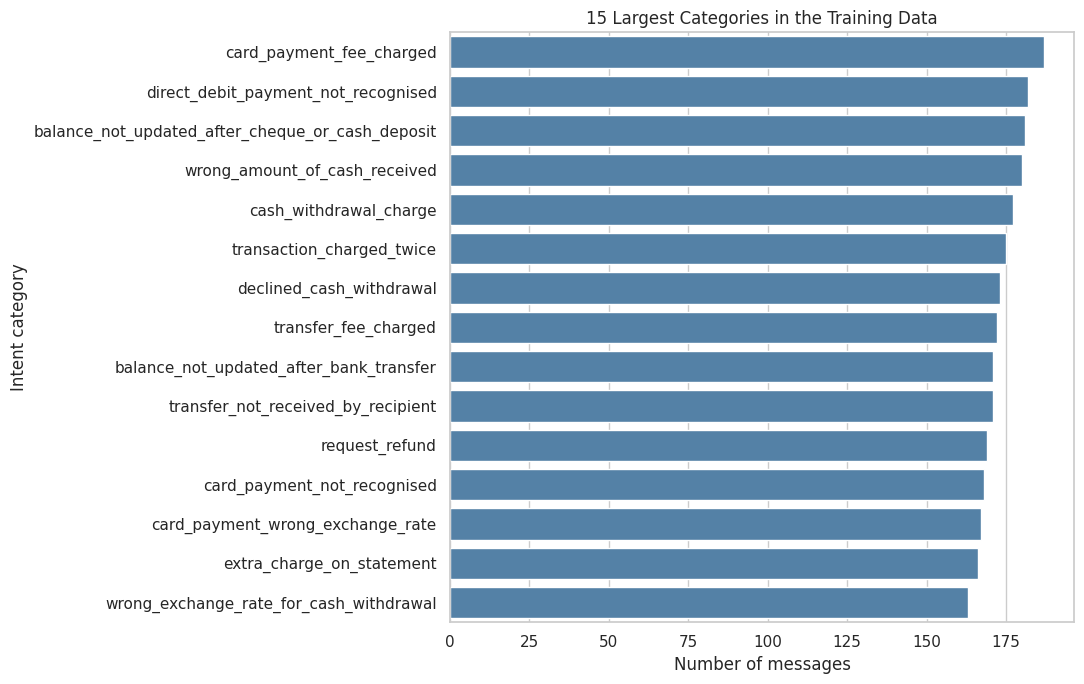

Smallest category: 35 messages
Largest category: 187 messages


In [ ]:
category_counts = train_df["label"].value_counts()

top_categories = (
    category_counts.head(15)
    .rename_axis("label")
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(11, 7))

sns.barplot(
    data=top_categories,
    x="count",
    y="label",
    color="steelblue",
    ax=ax,
)

ax.set(
    title="15 Largest Categories in the Training Data",
    xlabel="Number of messages",
    ylabel="Intent category",
)

plt.tight_layout()
plt.show()

print("Smallest category:", category_counts.min(), "messages")
print("Largest category:", category_counts.max(), "messages")

In [ ]:

development_keys = make_text_key(train_df["text"])
reserved_test_keys = set(make_text_key(test_df["text"]))

overlap_mask = development_keys.isin(reserved_test_keys)

removed_development_rows = train_df.loc[overlap_mask].copy()

clean_development_df = (
    train_df.loc[~overlap_mask]
    .copy()
    .reset_index(drop=True)
)

print("Original development rows:", len(train_df))
print(
    "Unique overlapping messages:",
    development_keys[overlap_mask].nunique(),
)
print("Development rows excluded:", overlap_mask.sum())
print("Clean development rows:", len(clean_development_df))
print("Test rows retained:", len(test_df))

assert not (
    set(make_text_key(clean_development_df["text"]))
    & reserved_test_keys
), "Overlap remains."

assert (
    set(clean_development_df["label"])
    == set(train_df["label"])
), "Cleaning removed an entire category."

Original development rows: 10003
Unique overlapping messages: 7
Development rows excluded: 7
Clean development rows: 9996
Test rows retained: 3080


In [ ]:
def make_text_key(text_series):
    return (
        text_series
        .fillna("")
        .str.casefold()
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


# Start from the original training data.
development_df = train_df.copy()
development_df["text_key"] = make_text_key(
    development_df["text"]
)

# Compare against test text only.
test_keys = set(make_text_key(test_df["text"]))

overlap_mask = development_df["text_key"].isin(test_keys)

print("Original development rows:", len(development_df))
print(
    "Unique overlapping messages:",
    development_df.loc[overlap_mask, "text_key"].nunique(),
)
print("Rows to exclude:", int(overlap_mask.sum()))

# Actually remove overlapping development rows.
development_df = (
    development_df.loc[~overlap_mask]
    .copy()
    .reset_index(drop=True)
)

remaining_overlap = (
    set(development_df["text_key"]) & test_keys
)

assert len(remaining_overlap) == 0, "Overlap remains."

assert set(development_df["label"]) == set(train_df["label"]), (
    "Cleaning removed an entire category."
)

print("\nClean development rows:", len(development_df))
print("Remaining overlap:", len(remaining_overlap))
print("Test rows unchanged:", len(test_df))

Original development rows: 10003
Unique overlapping messages: 7
Rows to exclude: 7

Clean development rows: 9996
Remaining overlap: 0
Test rows unchanged: 3080


In [ ]:
#create a traning and validation split
from sklearn.model_selection import StratifiedGroupKFold

splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

fit_indices, validation_indices = next(
    splitter.split(
        X=development_df["text"],
        y=development_df["label"],
        groups=development_df["text_key"],
    )
)

fit_df = development_df.iloc[fit_indices].copy()
validation_df = development_df.iloc[validation_indices].copy()

X_train = fit_df["text"]
y_train = fit_df["label"]

X_val = validation_df["text"]
y_val = validation_df["label"]

print("Training examples:", len(X_train))
print("Validation examples:", len(X_val))
print("Reserved test examples:", len(test_df))

Training examples: 7996
Validation examples: 2000
Reserved test examples: 3080


In [ ]:
shared_keys = (
    set(fit_df["text_key"])
    & set(validation_df["text_key"])
)

assert len(shared_keys) == 0, (
    "Matching messages appear in both training and validation."
)

all_labels = set(development_df["label"])

assert set(y_train) == all_labels, (
    "Some categories are missing from training."
)

assert set(y_val) == all_labels, (
    "Some categories are missing from validation."
)

split_summary = pd.DataFrame({
    "Split": ["Training", "Validation", "Reserved test"],
    "Messages": [
        len(fit_df),
        len(validation_df),
        len(test_df),
    ],
})

display(split_summary)

print("Training categories:", y_train.nunique())
print("Validation categories:", y_val.nunique())
print("Shared normalized training/validation messages:", len(shared_keys))

,Split,Messages
0,Training,7996
1,Validation,2000
2,Reserved test,3080


Training categories: 77
Validation categories: 77
Shared normalized training/validation messages: 0


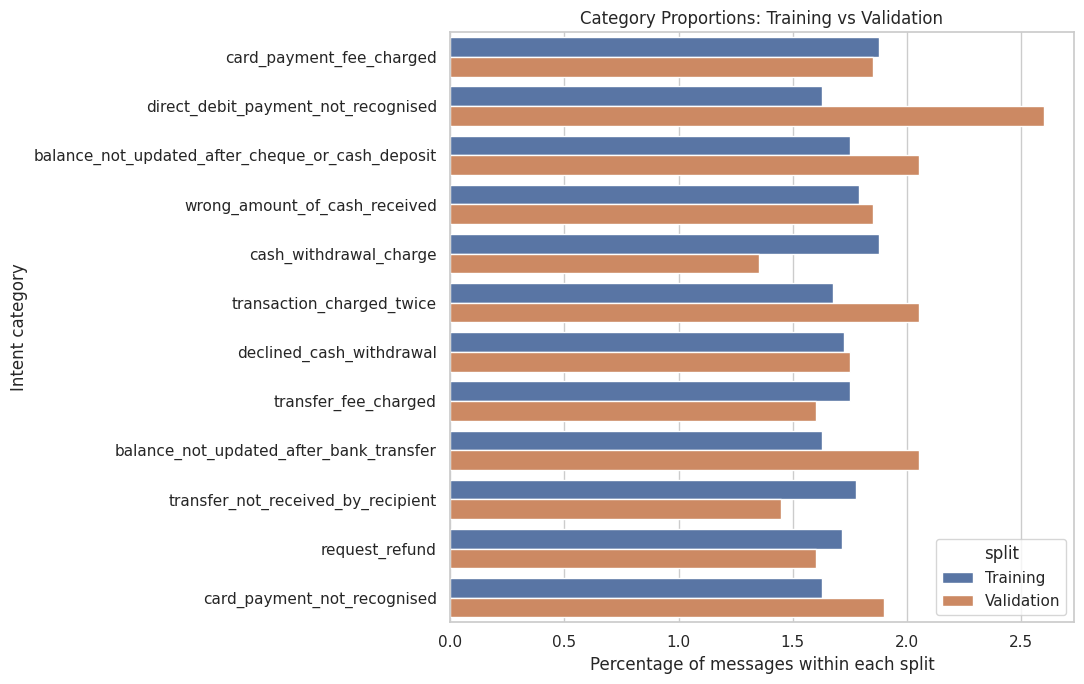

In [ ]:
# visualize category proportions
largest_labels = (
    development_df["label"]
    .value_counts()
    .head(12)
    .index
)

proportions = pd.DataFrame({
    "Training": y_train.value_counts(normalize=True),
    "Validation": y_val.value_counts(normalize=True),
}).fillna(0)

plot_data = (
    proportions.loc[largest_labels]
    .mul(100)
    .rename_axis("label")
    .reset_index()
    .melt(
        id_vars="label",
        var_name="split",
        value_name="percentage",
    )
)

fig, ax = plt.subplots(figsize=(11, 7))

sns.barplot(
    data=plot_data,
    x="percentage",
    y="label",
    hue="split",
    ax=ax,
)

ax.set(
    title="Category Proportions: Training vs Validation",
    xlabel="Percentage of messages within each split",
    ylabel="Intent category",
)

plt.tight_layout()
plt.show()

In [ ]:
# simple baseline
from sklearn.metrics import accuracy_score, f1_score

most_common_label = y_train.value_counts().idxmax()

baseline_predictions = [
    most_common_label
] * len(y_val)

baseline_accuracy = accuracy_score(
    y_val,
    baseline_predictions,
)

baseline_macro_f1 = f1_score(
    y_val,
    baseline_predictions,
    average="macro",
    zero_division=0,
)

baseline_results = pd.DataFrame({
    "Model": ["Most-frequent-category baseline"],
    "Accuracy": [baseline_accuracy],
    "Macro_F1": [baseline_macro_f1],
})

print("Always predicts:", most_common_label)
display(baseline_results.round(4))

Always predicts: card_payment_fee_charged


,Model,Accuracy,Macro_F1
0,Most-frequent-category baseline,0.0185,0.0005


In [ ]:
# understand word count
from sklearn.feature_extraction.text import CountVectorizer

example_messages = [
    "card payment failed",
    "card payment pending",
    "bank transfer failed",
]

example_vectorizer = CountVectorizer()

example_counts = example_vectorizer.fit_transform(
    example_messages
)

count_table = pd.DataFrame(
    example_counts.toarray(),
    columns=example_vectorizer.get_feature_names_out(),
    index=example_messages,
)

display(count_table)

,bank,card,failed,payment,pending,transfer
card payment failed,0,1,1,1,0,0
card payment pending,0,1,0,1,1,0
bank transfer failed,1,0,1,0,0,1


In [ ]:
# Build TF-IDF features
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=20_000,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

print("Training feature matrix:", X_train_tfidf.shape)
print("Validation feature matrix:", X_val_tfidf.shape)

print("\nExample features:")
print(tfidf.get_feature_names_out()[:20])

Training feature matrix: (7996, 8964)
Validation feature matrix: (2000, 8964)

Example features:
['00' '00 in' '000' '10' '10 minutes' '10 pounds' '100' '100 all'
 '100 but' '18' '18 to' '18 years' '20' '20 but' '20 came' '20 what' '200'
 '2018' '30' '30 pounds']


Message: I am still waiting on my card?
Label: card_arrival


,feature,weight
8,waiting on,0.475349
6,am still,0.415495
7,still waiting,0.410611
2,waiting,0.355641
1,still,0.262807
9,on my,0.253728
0,am,0.250410
3,on,0.211880
10,my card,0.184167
5,card,0.143853


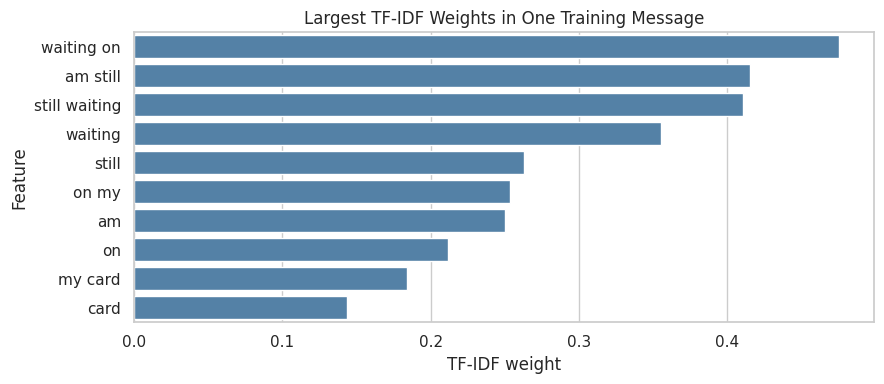

In [ ]:
# Inspect one message’s strongest features
feature_names = tfidf.get_feature_names_out()

row_number = 0
message_vector = X_train_tfidf.getrow(row_number)

feature_weights = pd.DataFrame({
    "feature": feature_names[message_vector.indices],
    "weight": message_vector.data,
}).sort_values("weight", ascending=False)

print("Message:", X_train.iloc[row_number])
print("Label:", y_train.iloc[row_number])

display(feature_weights.head(10))

if not feature_weights.empty:
    fig, ax = plt.subplots(figsize=(9, 4))

    sns.barplot(
        data=feature_weights.head(10),
        x="weight",
        y="feature",
        color="steelblue",
        ax=ax,
    )

    ax.set(
        title="Largest TF-IDF Weights in One Training Message",
        xlabel="TF-IDF weight",
        ylabel="Feature",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
# Train logistic regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
)

lr_model.fit(X_train_tfidf, y_train)

print("Training completed.")
print("Number of learned categories:", len(lr_model.classes_))
print("Optimization iterations:", lr_model.n_iter_)

Training completed.
Number of learned categories: 77
Optimization iterations: [34]


In [ ]:
# Compare against the baseline
from sklearn.metrics import accuracy_score, f1_score

val_predictions = lr_model.predict(X_val_tfidf)

lr_accuracy = accuracy_score(y_val, val_predictions)

lr_macro_f1 = f1_score(
    y_val,
    val_predictions,
    average="macro",
    zero_division=0,
)

comparison = pd.concat(
    [
        baseline_results,
        pd.DataFrame({
            "Model": ["TF-IDF + Logistic Regression"],
            "Accuracy": [lr_accuracy],
            "Macro_F1": [lr_macro_f1],
        }),
    ],
    ignore_index=True,
)

display(comparison.round(4))

print(f"Logistic regression validation accuracy: {lr_accuracy:.2%}")
print(f"Logistic regression validation macro F1: {lr_macro_f1:.4f}")

,Model,Accuracy,Macro_F1
0,Most-frequent-category baseline,0.0185,0.0005
1,TF-IDF + Logistic Regression,0.8380,0.8300


Logistic regression validation accuracy: 83.80%
Logistic regression validation macro F1: 0.8300


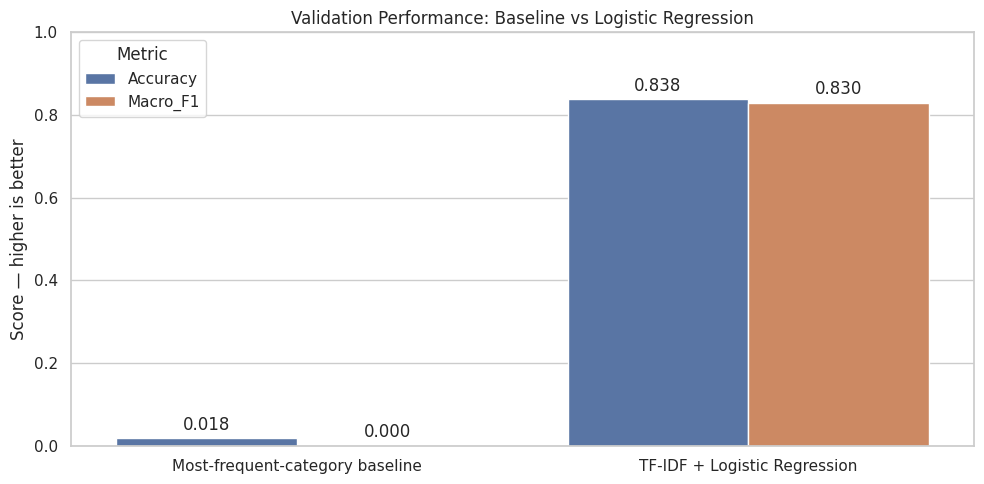

In [ ]:
#Visualize the comparison
comparison_long = comparison.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Macro_F1"],
    var_name="Metric",
    value_name="Score",
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=comparison_long,
    x="Model",
    y="Score",
    hue="Metric",
    ax=ax,
)

ax.set(
    title="Validation Performance: Baseline vs Logistic Regression",
    xlabel="",
    ylabel="Score — higher is better",
    ylim=(0, 1),
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

In [ ]:
# Inspect performance by category
from sklearn.metrics import classification_report

report = classification_report(
    y_val,
    val_predictions,
    labels=lr_model.classes_,
    output_dict=True,
    zero_division=0,
)

per_class_results = (
    pd.DataFrame(report)
    .T
    .loc[
        lr_model.classes_,
        ["precision", "recall", "f1-score", "support"],
    ]
)

per_class_results["support"] = (
    per_class_results["support"].astype(int)
)

print("Ten categories with the lowest validation F1:")
display(
    per_class_results
    .sort_values("f1-score")
    .head(10)
    .round(3)
)

Ten categories with the lowest validation F1:


,precision,recall,f1-score,support
virtual_card_not_working,1.000,0.250,0.400,8
card_not_working,0.542,0.722,0.619,18
transfer_not_received_by_recipient,0.679,0.655,0.667,29
card_acceptance,0.800,0.571,0.667,7
topping_up_by_card,0.941,0.552,0.696,29
why_verify_identity,0.857,0.600,0.706,30
card_arrival,0.590,0.885,0.708,26
top_up_by_bank_transfer_charge,0.909,0.588,0.714,17
wrong_exchange_rate_for_cash_withdrawal,0.833,0.625,0.714,32
failed_transfer,0.633,0.826,0.717,23


In [ ]:
#Read actual mistakes
validation_results = pd.DataFrame({
    "text": X_val.to_numpy(),
    "actual": y_val.to_numpy(),
    "predicted": val_predictions,
})

validation_results["correct"] = (
    validation_results["actual"]
    == validation_results["predicted"]
)

errors = validation_results[
    ~validation_results["correct"]
].copy()

print("Incorrect predictions:", len(errors))
print("Total validation messages:", len(validation_results))

with pd.option_context("display.max_colwidth", 150):
    display(
        errors.sample(
            n=min(10, len(errors)),
            random_state=42,
        )
    )

Incorrect predictions: 324
Total validation messages: 2000


,text,actual,predicted,correct
831,The money disappeared after I topped up my account.,topping_up_by_card,top_up_reverted,False
723,Is the identity check part of bank policy?,why_verify_identity,verify_my_identity,False
843,my top up isnt there yet where do i find it,topping_up_by_card,pending_top_up,False
66,How do you do exchanges?,exchange_rate,fiat_currency_support,False
1132,"Hello. I bought an item a while ago, and have since requested a refund. However, upon checking my online statements, it seems that I haven't been...",Refund_not_showing_up,request_refund,False
801,Do I have to pick a creditcard brand?,visa_or_mastercard,getting_spare_card,False
1433,What are then rules on beneficiaries?,beneficiary_not_allowed,supported_cards_and_currencies,False
1283,My account seems a bit off and getting weird charges.,transaction_charged_twice,terminate_account,False
1633,I think the exchange rate was incorrect.,wrong_exchange_rate_for_cash_withdrawal,card_payment_wrong_exchange_rate,False
871,How many payments can I make using a virtual card?,disposable_card_limits,getting_virtual_card,False


In [ ]:
#Compare training and validation performance
train_predictions = lr_model.predict(X_train_tfidf)

performance = pd.DataFrame({
    "Split": ["Training", "Validation"],
    "Accuracy": [
        accuracy_score(y_train, train_predictions),
        accuracy_score(y_val, val_predictions),
    ],
    "Macro_F1": [
        f1_score(
            y_train,
            train_predictions,
            average="macro",
            zero_division=0,
        ),
        f1_score(
            y_val,
            val_predictions,
            average="macro",
            zero_division=0,
        ),
    ],
})

display(performance.round(4))

,Split,Accuracy,Macro_F1
0,Training,0.9442,0.9408
1,Validation,0.8380,0.8300


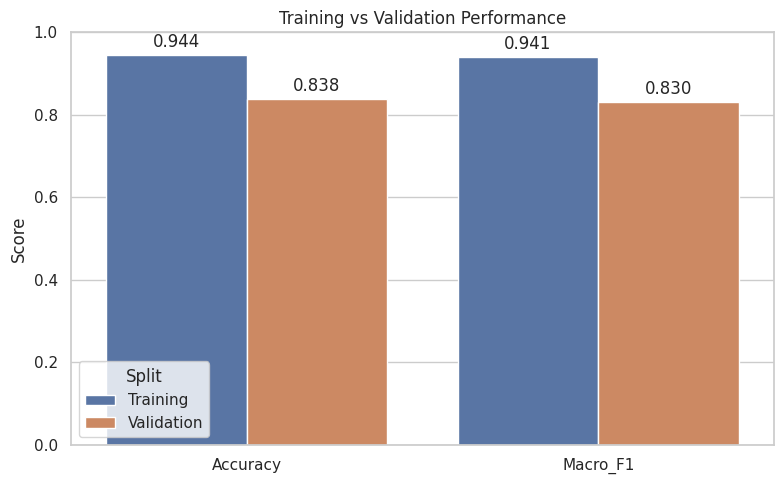

In [ ]:
#Visualize the gap
performance_long = performance.melt(
    id_vars="Split",
    value_vars=["Accuracy", "Macro_F1"],
    var_name="Metric",
    value_name="Score",
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=performance_long,
    x="Metric",
    y="Score",
    hue="Split",
    ax=ax,
)

ax.set(
    title="Training vs Validation Performance",
    xlabel="",
    ylabel="Score",
    ylim=(0, 1),
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

In [ ]:
#Find the most frequent confusion pairs
confusion_pairs = (
    errors.groupby(["actual", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

display(confusion_pairs.head(10))

,actual,predicted,count
0,top_up_failed,pending_top_up,9
1,why_verify_identity,verify_my_identity,6
2,direct_debit_payment_not_recognised,card_payment_not_recognised,5
3,top_up_by_bank_transfer_charge,top_up_by_card_charge,5
4,get_disposable_virtual_card,disposable_card_limits,5
5,wrong_exchange_rate_for_cash_withdrawal,card_payment_wrong_exchange_rate,5
6,topping_up_by_card,top_up_reverted,4
7,why_verify_identity,unable_to_verify_identity,4
8,reverted_card_payment?,declined_card_payment,4
9,transfer_fee_charged,card_payment_fee_charged,4


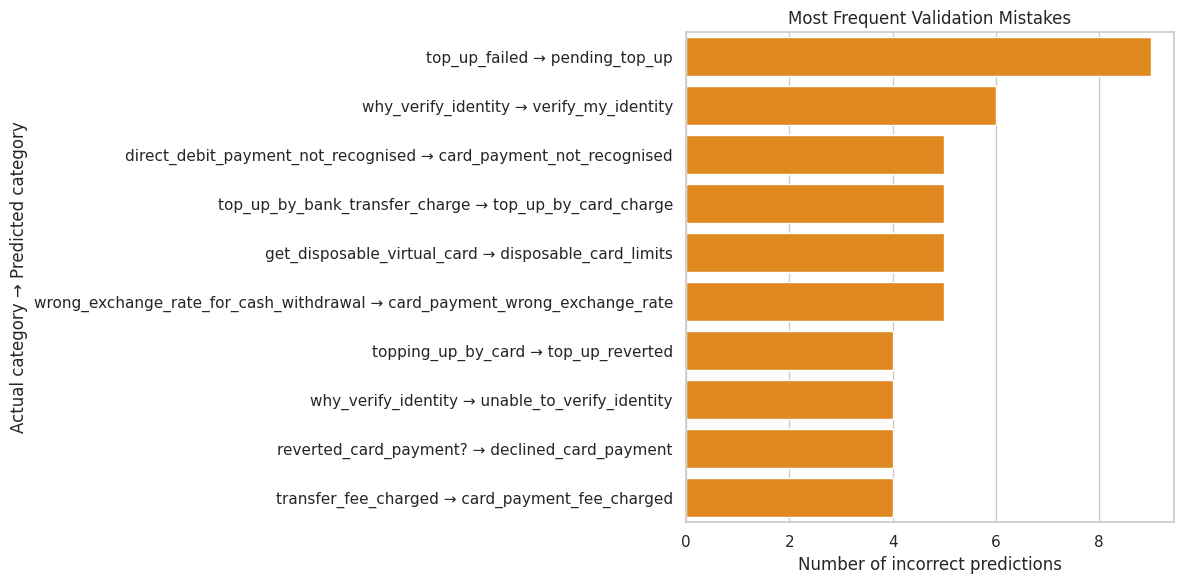

In [ ]:
#Visualize those mistakes
top_confusions = confusion_pairs.head(10).copy()

top_confusions["pair"] = (
    top_confusions["actual"]
    + " → "
    + top_confusions["predicted"]
)

if not top_confusions.empty:
    fig, ax = plt.subplots(figsize=(12, 6))

    sns.barplot(
        data=top_confusions,
        x="count",
        y="pair",
        color="darkorange",
        ax=ax,
    )

    ax.set(
        title="Most Frequent Validation Mistakes",
        xlabel="Number of incorrect predictions",
        ylabel="Actual category → Predicted category",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
#Compare a small set of values
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

candidate_models = {1.0: lr_model}
experiment_rows = []

for c_value in [0.1, 1.0, 3.0, 10.0]:
    print(f"Evaluating C={c_value}...")

    if c_value not in candidate_models:
        candidate = LogisticRegression(
            C=c_value,
            solver="lbfgs",
            max_iter=1000,
        )

        candidate.fit(X_train_tfidf, y_train)
        candidate_models[c_value] = candidate

    candidate = candidate_models[c_value]

    train_pred = candidate.predict(X_train_tfidf)
    val_pred = candidate.predict(X_val_tfidf)

    experiment_rows.append({
        "C": c_value,
        "Train_Accuracy": accuracy_score(y_train, train_pred),
        "Val_Accuracy": accuracy_score(y_val, val_pred),
        "Train_Macro_F1": f1_score(
            y_train,
            train_pred,
            average="macro",
            zero_division=0,
        ),
        "Val_Macro_F1": f1_score(
            y_val,
            val_pred,
            average="macro",
            zero_division=0,
        ),
    })

tuning_results = pd.DataFrame(experiment_rows)

display(tuning_results.round(4))

Evaluating C=0.1...
Evaluating C=1.0...
Evaluating C=3.0...
Evaluating C=10.0...


,C,Train_Accuracy,Val_Accuracy,Train_Macro_F1,Val_Macro_F1
0,0.1,0.7446,0.6670,0.6893,0.6166
1,1.0,0.9442,0.8380,0.9408,0.8300
2,3.0,0.9862,0.8570,0.9853,0.8537
3,10.0,0.9986,0.8635,0.9986,0.8599


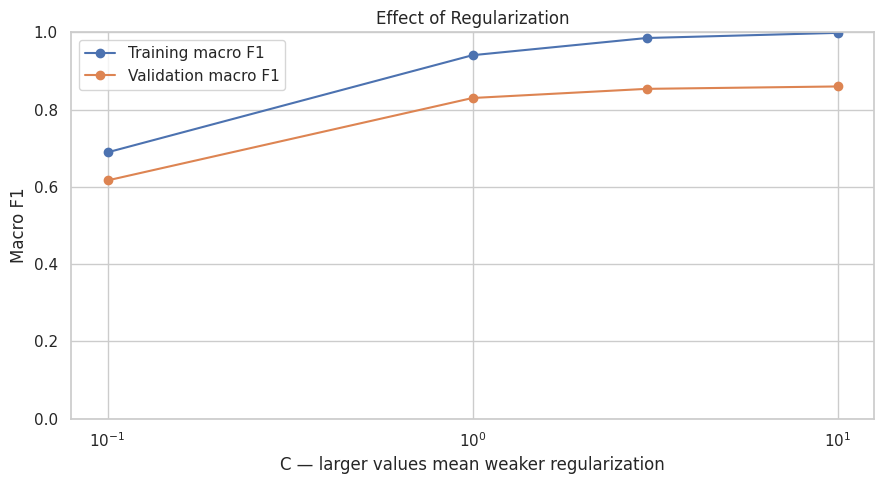

In [ ]:
#Visualize the results
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    tuning_results["C"],
    tuning_results["Train_Macro_F1"],
    marker="o",
    label="Training macro F1",
)

ax.plot(
    tuning_results["C"],
    tuning_results["Val_Macro_F1"],
    marker="o",
    label="Validation macro F1",
)

ax.set_xscale("log")

ax.set(
    title="Effect of Regularization",
    xlabel="C — larger values mean weaker regularization",
    ylabel="Macro F1",
    ylim=(0, 1),
)

ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Select using validation macro F1
ranked_results = tuning_results.sort_values(
    by=["Val_Macro_F1", "C"],
    ascending=[False, True],
)

best_c = float(ranked_results.iloc[0]["C"])
best_model = candidate_models[best_c]

best_val_predictions = best_model.predict(X_val_tfidf)

print("Selected C:", best_c)

display(
    ranked_results[
        ["C", "Val_Accuracy", "Val_Macro_F1"]
    ].round(4)
)

original_f1 = tuning_results.loc[
    tuning_results["C"] == 1.0,
    "Val_Macro_F1",
].iloc[0]

selected_f1 = ranked_results.iloc[0]["Val_Macro_F1"]

print(
    "Validation macro F1 change versus C=1.0:",
    f"{selected_f1 - original_f1:+.4f}",
)

Selected C: 10.0


,C,Val_Accuracy,Val_Macro_F1
3,10.0,0.8635,0.8599
2,3.0,0.8570,0.8537
1,1.0,0.8380,0.8300
0,0.1,0.6670,0.6166


Validation macro F1 change versus C=1.0: +0.0299


In [ ]:
# Confirm the data is ready
ranked_results = tuning_results.sort_values(
    by=["Val_Macro_F1", "C"],
    ascending=[False, True],
)

best_c = float(ranked_results.iloc[0]["C"])
best_model = candidate_models[best_c]

best_val_predictions = best_model.predict(X_val_tfidf)

print("Selected C:", best_c)

display(
    ranked_results[
        ["C", "Val_Accuracy", "Val_Macro_F1"]
    ].round(4)
)

original_f1 = tuning_results.loc[
    tuning_results["C"] == 1.0,
    "Val_Macro_F1",
].iloc[0]

selected_f1 = ranked_results.iloc[0]["Val_Macro_F1"]

print(
    "Validation macro F1 change versus C=1.0:",
    f"{selected_f1 - original_f1:+.4f}",
)

Selected C: 10.0


,C,Val_Accuracy,Val_Macro_F1
3,10.0,0.8635,0.8599
2,3.0,0.8570,0.8537
1,1.0,0.8380,0.8300
0,0.1,0.6670,0.6166


Validation macro F1 change versus C=1.0: +0.0299


In [ ]:
# Check the cleaned data, not the original train_df.
shared_test_messages = (
    set(make_text_key(development_df["text"]))
    & set(make_text_key(test_df["text"]))
)

print("Selected C:", best_c)
print("Clean development messages:", len(development_df))
print("Test messages:", len(test_df))
print("Normalized overlap:", len(shared_test_messages))

assert len(shared_test_messages) == 0, (
    "The development data still contains overlapping messages. "
    "Check that Cell 7 uses clean_development_df."
)

assert test_df[["text", "label"]].notna().all().all(), (
    "The test set contains missing values."
)

assert test_df["text"].str.strip().ne("").all(), (
    "The test set contains blank messages."
)

assert set(test_df["label"]).issubset(
    set(development_df["label"])
), "The test set contains a category absent from development."

print("Checks passed. Ready for final training.")

Selected C: 10.0
Clean development messages: 9996
Test messages: 3080
Normalized overlap: 0
Checks passed. Ready for final training.


In [ ]:
# Train the final pipeline
from sklearn.base import clone
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ("tfidf", clone(tfidf)),
    ("classifier", clone(best_model)),
])

final_pipeline.fit(
    development_df["text"],
    development_df["label"],
)

print("Final training completed.")
print(
    "Selected C:",
    final_pipeline.named_steps["classifier"].C,
)

Final training completed.
Selected C: 10.0


In [ ]:
# Evaluate on the reserved test set
from sklearn.metrics import accuracy_score, f1_score

test_predictions = final_pipeline.predict(test_df["text"])

majority_label = (
       development_df["label"].value_counts().idxmax()
)

baseline_test_predictions = [majority_label] * len(test_df)

test_rows = []

for model_name, predictions in [
    ("Majority baseline", baseline_test_predictions),
    ("TF-IDF + Logistic Regression", test_predictions),
]:
    test_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            test_df["label"], predictions
        ),
        "Macro_F1": f1_score(
            test_df["label"],
            predictions,
            average="macro",
            zero_division=0,
        ),
    })

test_metrics = pd.DataFrame(test_rows)

display(test_metrics.round(4))

correct = (
    test_predictions == test_df["label"].to_numpy()
).sum()

print(f"Correct predictions: {correct}/{len(test_df)}")
print(f"Incorrect predictions: {len(test_df) - correct}")

,Model,Accuracy,Macro_F1
0,Majority baseline,0.0130,0.0003
1,TF-IDF + Logistic Regression,0.8903,0.8906


Correct predictions: 2742/3080
Incorrect predictions: 338


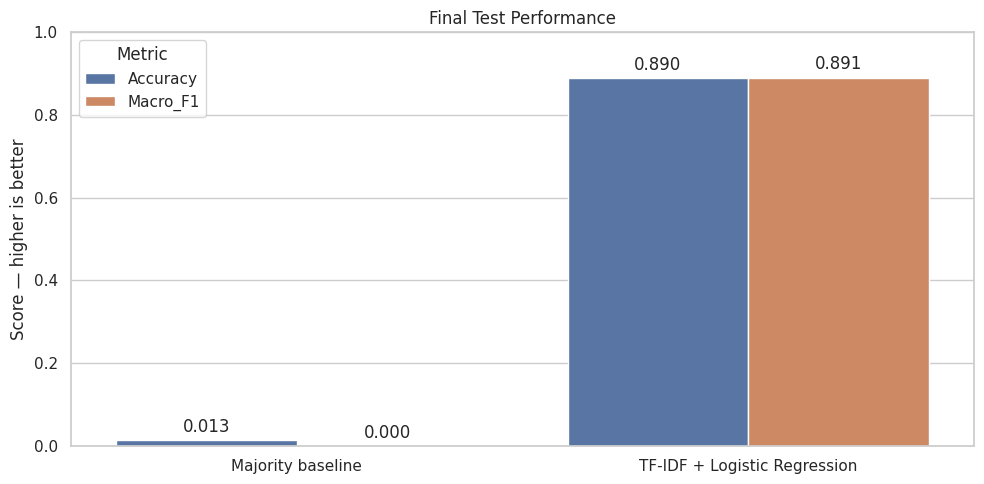

In [ ]:
# Visualize the comparison
plot_data = test_metrics.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Macro_F1"],
    var_name="Metric",
    value_name="Score",
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=plot_data,
    x="Model",
    y="Score",
    hue="Metric",
    ax=ax,
)

ax.set(
    title="Final Test Performance",
    xlabel="",
    ylabel="Score — higher is better",
    ylim=(0, 1),
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

In [ ]:
#Predict new messages
new_messages = [
    "I have been charged twice for the same purchase.",
    "My bank card has not arrived yet.",
    "I forgot the passcode for my account.",
    "The cash machine kept my card.",
]

new_predictions = final_pipeline.predict(new_messages)

display(pd.DataFrame({
    "Message": new_messages,
    "Predicted intent": new_predictions,
}))

,Message,Predicted intent
0,I have been charged twice for the same purchase.,transaction_charged_twice
1,My bank card has not arrived yet.,balance_not_updated_after_bank_transfer
2,I forgot the passcode for my account.,passcode_forgotten
3,The cash machine kept my card.,card_swallowed


In [ ]:
import json
import platform
from pathlib import Path
from importlib.metadata import version

import joblib

output_dir = Path("/content/banking_classifier_export")
output_dir.mkdir(exist_ok=True)

model_path = output_dir / "banking_intent_pipeline.joblib"

joblib.dump(
    final_pipeline,
    model_path,
    compress=3,
)

test_metrics.to_csv(
    output_dir / "test_metrics.csv",
    index=False,
)

tuning_results.to_csv(
    output_dir / "validation_tuning_results.csv",
    index=False,
)

package_versions = {
    package: version(package)
    for package in [
        "scikit-learn",
        "numpy",
        "scipy",
        "pandas",
        "joblib",
    ]
}

metadata = {
    "dataset": "BANKING77",
    "model": "TF-IDF + Logistic Regression",
    "selected_C": float(
        final_pipeline.named_steps["classifier"].C
    ),
    "original_development_rows": len(train_df),
    "clean_development_rows": len(development_df),
    "excluded_development_rows": (
        len(train_df) - len(development_df)
    ),
    "test_rows": len(test_df),
    "categories": (
        final_pipeline.named_steps["classifier"]
        .classes_.tolist()
    ),
    "overlap_policy": (
        "Exclude development messages matching test messages "
        "after case and whitespace normalization."
    ),
    "selection_metric": "Validation macro F1",
    "python_version": platform.python_version(),
    "package_versions": package_versions,
}

(output_dir / "metadata.json").write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

(output_dir / "requirements.txt").write_text(
    "\n".join(
        f"{package}=={package_version}"
        for package, package_version in package_versions.items()
    ) + "\n",
    encoding="utf-8",
)

print("Saved files:")
for path in sorted(output_dir.iterdir()):
    print("-", path.name)

Saved files:
- banking_intent_pipeline.joblib
- metadata.json
- requirements.txt
- test_metrics.csv
- validation_tuning_results.csv


In [ ]:
# Verify the saved model
import numpy as np

loaded_pipeline = joblib.load(model_path)

original_predictions = final_pipeline.predict(new_messages)
reloaded_predictions = loaded_pipeline.predict(new_messages)

np.testing.assert_array_equal(
    original_predictions,
    reloaded_predictions,
)

np.testing.assert_allclose(
    final_pipeline.predict_proba(new_messages),
    loaded_pipeline.predict_proba(new_messages),
)

print("Reload check passed: predictions and probabilities match.")

Reload check passed: predictions and probabilities match.


In [ ]:
#Download everything together
import shutil
from google.colab import files

archive_path = shutil.make_archive(
    "/content/banking_classifier_export",
    "zip",
    root_dir=output_dir,
)

files.download(archive_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>